In [1]:
!pip install -q langgraph langchain langchain-openai langchain-community langchain-huggingface faiss-cpu sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
from google.colab import userdata

from typing import TypedDict, Annotated, Literal
import operator

from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
    AIMessage,
    ToolMessage,
)
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_community.vectorstores import FAISS

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command


api_key = userdata.get("OpenRouter")

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)


/tmp/ipykernel_1767/3899425319.py:20: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [3]:
class TriageResult(BaseModel):
    department: Literal["finance", "technical", "general"]


class SentimentResult(BaseModel):
    sentiment: Literal["Positive", "Neutral", "Negative"]


class SupportState(TypedDict, total=False):
    # Important: these are LangChain messages, not strings.
    messages: Annotated[list[BaseMessage], operator.add]

    user_id: str
    sentiment: str
    department: str
    next_step: str
    response: str


In [4]:
def get_last_human_message(state: SupportState) -> HumanMessage:
    """Always return the original/latest user message, even after AI/tool messages were appended."""
    for message in reversed(state.get("messages", [])):
        if isinstance(message, HumanMessage):
            return message

    raise ValueError("No HumanMessage exists in state['messages'].")


## Finance tools


In [5]:
@tool
def check_subscription_status(user_id: str) -> str:
    """Check whether a user's subscription is active or expired."""

    fake_database = {
        "12345": "Expired",
        "67890": "Active",
        "11111": "Active",
    }

    return fake_database.get(user_id, "User not found")


@tool
def process_refund(transaction_id: str) -> str:
    """Process a mock refund for a transaction."""

    return f"Refund for transaction {transaction_id} has been approved."


finance_tools = {
    check_subscription_status.name: check_subscription_status,
    process_refund.name: process_refund,
}


## Small RAG knowledge base


In [6]:
documents = [
    Document(
        page_content=(
            "Password Reset:\n"
            "To reset your password, go to Settings, select Security and click "
            "Reset Password. A password reset link will be sent to your registered "
            "email address."
        )
    ),
    Document(
        page_content=(
            "Login Problems:\n"
            "If you cannot log into your account, clear your browser cache and cookies, "
            "restart your browser and try again."
        )
    ),
    Document(
        page_content=(
            "Application Crash:\n"
            "If the application crashes, first update the application to the latest "
            "version and restart your device."
        )
    ),
]

# Local multilingual embeddings make the RAG independent from OpenRouter's
# embedding endpoint and work better for Persian queries.
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

vector_store = FAISS.from_documents(documents, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 2})


@tool
def search_knowledge_base(query: str) -> str:
    """Search the technical knowledge base using RAG."""

    docs = retriever.invoke(query)

    if not docs:
        return "NO_RELEVANT_INFORMATION"

    return "\n\n".join(doc.page_content for doc in docs)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Specialized LLMs


In [7]:
triage_llm = llm.with_structured_output(TriageResult)

finance_llm = llm.bind_tools([
    check_subscription_status,
    process_refund,
])

sentiment_llm = llm.with_structured_output(SentimentResult)


## Nodes


In [8]:
def triage_node(state: SupportState):
    user_message = get_last_human_message(state)

    result = triage_llm.invoke([
        SystemMessage(
            content="""
You are the triage agent for a customer-support system.

Classify the user's MAIN intent into exactly one category:

finance:
- subscription status
- payment
- charge
- transaction
- refund
- billing

technical:
- password reset
- login issue
- application crash
- bug
- product technical problem

general:
- greeting
- general information
- anything that is neither finance nor technical

Important:
A subscription that is not working is still FINANCE when the user is asking
about subscription/account status.

Return the structured classification only.
"""
        ),
        user_message,
    ])

    return {"department": result.department}


def finance_node(state: SupportState):
    user_message = get_last_human_message(state)

    tool_decision = finance_llm.invoke([
        SystemMessage(
            content="""
You are the Billing Specialist.

Rules:
1. For subscription status, call check_subscription_status.
2. For a refund request with a transaction id, call process_refund.
3. Do not invent tool results.
4. Do not answer technical questions.
5. If required information is missing, ask for that information.
"""
        ),
        user_message,
    ])

    # If no tool is needed/called, preserve the model's response.
    if not tool_decision.tool_calls:
        text = tool_decision.content or (
            "برای انجام درخواست مالی، لطفاً شناسه کاربر یا شناسه تراکنش را ارسال کنید."
        )
        final_message = AIMessage(content=text)
        return {
            "messages": [final_message],
            "response": text,
        }

    tool_messages = []
    result_lines = []

    for call in tool_decision.tool_calls:
        tool_name = call["name"]
        tool_args = call["args"]

        selected_tool = finance_tools.get(tool_name)
        if selected_tool is None:
            continue

        tool_result = selected_tool.invoke(tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(tool_result),
                tool_call_id=call["id"],
            )
        )

        result_lines.append(
            f"{tool_name}: {tool_result}"
        )

    final_response = llm.invoke([
        SystemMessage(
            content="""
You are a billing support specialist.
Answer in the same language as the user.
Use ONLY the supplied tool results.
Be short and clear.
Do not invent any status, id, refund, or transaction result.
"""
        ),
        user_message,
        HumanMessage(
            content="Tool results:\n" + "\n".join(result_lines)
        ),
    ])

    return {
        # Keep the tool-call message + tool results in graph history.
        "messages": [tool_decision, *tool_messages, final_response],
        "response": final_response.content,
    }


def technical_node(state: SupportState):
    user_message = get_last_human_message(state)

    context = search_knowledge_base.invoke({
        "query": user_message.content
    })

    response = llm.invoke([
        SystemMessage(
            content=f"""
You are the Technical Support Specialist.

You MUST answer only from the knowledge-base context below.
If the context does not directly support the answer, say that you do not
know based on the available documentation.
Do not fabricate steps or product behavior.

Knowledge-base context:
{context}
"""
        ),
        user_message,
    ])

    return {
        "messages": [response],
        "response": response.content,
    }


def general_node(state: SupportState):
    user_message = get_last_human_message(state)

    response = llm.invoke([
        SystemMessage(
            content="You are a concise general customer-support assistant."
        ),
        user_message,
    ])

    return {
        "messages": [response],
        "response": response.content,
    }


def sentiment_node(state: SupportState):
    # Critical fix: inspect the USER message, not the latest AI answer.
    user_message = get_last_human_message(state)

    result = sentiment_llm.invoke([
        SystemMessage(
            content="""
Analyze the CUSTOMER'S tone.

Negative:
- anger
- accusation
- insults
- strong dissatisfaction
- threats
- explicit demand to speak with a manager because of dissatisfaction

Neutral:
- ordinary requests/questions without clear positive or negative emotion

Positive:
- thanks, satisfaction, praise

Return the structured sentiment only.
"""
        ),
        user_message,
    ])

    return {"sentiment": result.sentiment}


def human_review_node(state: SupportState):
    user_message = get_last_human_message(state)

    manager_action = interrupt({
        "reason": "Negative customer sentiment detected",
        "user_message": user_message.content,
        "draft_response": state.get("response", ""),
        "instruction": (
            "A human manager must provide the final response. "
            "Resume the graph with Command(resume={'response': '...'})"
        ),
    })

    if isinstance(manager_action, dict):
        manager_response = manager_action.get("response", "")
    else:
        manager_response = str(manager_action)

    if not manager_response:
        manager_response = "درخواست برای بررسی انسانی ثبت شد."

    final_message = AIMessage(content=manager_response)

    return {
        "messages": [final_message],
        "response": manager_response,
    }


## Routing and graph


In [9]:
def route_department(state: SupportState):
    return state["department"]


def route_sentiment(state: SupportState):
    if state["sentiment"] == "Negative":
        return "human_review"
    return "end"


builder = StateGraph(SupportState)

builder.add_node("triage", triage_node)
builder.add_node("finance", finance_node)
builder.add_node("technical", technical_node)
builder.add_node("general", general_node)
builder.add_node("sentiment", sentiment_node)
builder.add_node("human_review", human_review_node)

builder.add_edge(START, "triage")

builder.add_conditional_edges(
    "triage",
    route_department,
    {
        "finance": "finance",
        "technical": "technical",
        "general": "general",
    },
)

builder.add_edge("finance", "sentiment")
builder.add_edge("technical", "sentiment")
builder.add_edge("general", "sentiment")

builder.add_conditional_edges(
    "sentiment",
    route_sentiment,
    {
        "human_review": "human_review",
        "end": END,
    },
)

builder.add_edge("human_review", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


## Graph image


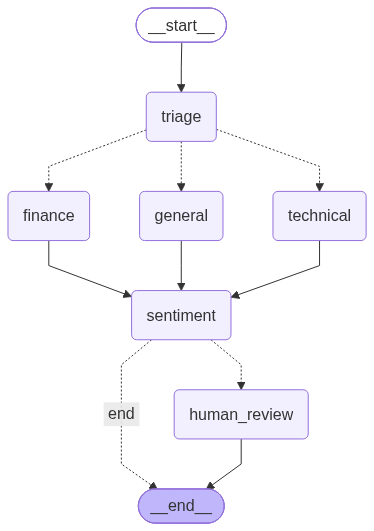

In [10]:
from IPython.display import Image, display

image_path = "langgraph_support_agent_fixed.png"
graph.get_graph().draw_mermaid_png(output_file_path=image_path)
display(Image(filename=image_path))


## Scenario 1 — Successful technical path


In [11]:
config_1 = {
    "configurable": {
        "thread_id": "scenario-1"
    }
}

result_1 = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="چطور می‌توانم رمز عبورم را ریست کنم؟"
            )
        ]
    },
    config=config_1,
)

print("Department:", result_1["department"])
print("Sentiment:", result_1["sentiment"])
print("Final response:", result_1["response"])


Department: technical
Sentiment: Neutral
Final response: برای ریست کردن رمز عبور خود، به تنظیمات (Settings) بروید، گزینه امنیت (Security) را انتخاب کنید و روی ریست رمز عبور (Reset Password) کلیک کنید. یک لینک ریست رمز عبور به آدرس ایمیل ثبت شده شما ارسال خواهد شد.


## Scenario 2 — Sensitive financial operation


In [12]:
config_2 = {
    "configurable": {
        "thread_id": "scenario-2"
    }
}

result_2 = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="اشتراک من کار نمی‌کند. آی‌دی من 12345 است."
            )
        ]
    },
    config=config_2,
)

print("Department:", result_2["department"])
print("Sentiment:", result_2["sentiment"])
print("Final response:", result_2["response"])


Department: finance
Sentiment: Negative
Final response: اشتراک شما منقضی شده است. لطفاً آن را تمدید کنید.


## Scenario 3 — Human escalation


In [13]:
config_3 = {
    "configurable": {
        "thread_id": "scenario-3"
    }
}

initial_3 = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "پول من را دزدیدید! این سرویس به درد نمی‌خورد! "
                    "می‌خواهم با مدیر حرف بزنم."
                )
            )
        ]
    },
    config=config_3,
)

print("Initial graph result:")
print(initial_3)

if "__interrupt__" in initial_3:
    print("\nHuman review required:")
    print(initial_3["__interrupt__"][0].value)

    manager_response = (
        "من مدیر ارشد هستم. عذرخواهی می‌کنم. "
        "مشکل شما را شخصاً پیگیری خواهم کرد."
    )

    final_3 = graph.invoke(
        Command(
            resume={
                "response": manager_response
            }
        ),
        config=config_3,
    )

    print("\nAfter manager intervention:")
    print("Final response:", final_3["response"])
else:
    print("\nERROR: Expected a human-review interrupt, but no interrupt occurred.")


Initial graph result:
{'messages': [HumanMessage(content='پول من را دزدیدید! این سرویس به درد نمی\u200cخورد! می\u200cخواهم با مدیر حرف بزنم.', additional_kwargs={}, response_metadata={}), AIMessage(content='متأسفم که با مشکلی مواجه شده\u200cاید. برای کمک به شما، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\u200cخواهید وضعیت اشتراک خود را بررسی کنم یا درخواست بازپرداخت دارید؟ اگر درخواست بازپرداخت دارید، لطفاً شناسه تراکنش را ارائه دهید.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'sentiment': 'Negative', 'department': 'finance', 'response': 'متأسفم که با مشکلی مواجه شده\u200cاید. برای کمک به شما، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\u200cخواهید وضعیت اشتراک خود را بررسی کنم یا درخواست بازپرداخت دارید؟ اگر درخواست بازپرداخت دارید، لطفاً شناسه تراکنش را ارائه دهید.', '__interrupt__': [Interrupt(value={'reason': 'Negative customer sentiment detected', 'user_message': 'پول من را دزدیدید! این سرویس به درد نمی\u200cخورد! می\u200cخواهم با مدیر حرف بزنم.